<a href="https://colab.research.google.com/github/Terry4715/MVO-backtest/blob/main/MVO_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%pip install yfinance
%pip install PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 8.2 MB/s eta 0:00:00


SDKs

In [3]:
# Get data
import yfinance as yf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [4]:
# create a stock portfolio
symbols = ['AAPL', 'MSFT', 'META', 'AMZN', 'XOM', 'UNH', 'JNJ', 'V', 'HD', 'ABBV', 'KO', 'DIS', 'T', 'UPS', 'LMT', 'CAT', 'F', 'MAR', 'O', 'HSY']

In [5]:
# get portfolio data
data = yf.download(symbols, start='2021-03-31', end='2026-03-31')
data['Close'].head()

/tmp/ipykernel_632/477952071.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols, start='2021-03-31', end='2026-03-31')
[*********************100%***********************]  20 of 20 completed


Ticker,AAPL,ABBV,AMZN,CAT,DIS,F,HD,HSY,JNJ,KO,LMT,MAR,META,MSFT,O,T,UNH,UPS,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2021-03-31,118.864052,88.639099,154.703995,211.065796,180.274628,9.080655,268.123627,139.177948,141.902588,45.414135,320.736877,142.281143,292.236725,225.746414,47.331772,16.354572,341.514191,134.971207,203.663803,45.787292
2021-04-01,119.691200,88.884804,158.050003,211.857758,184.622253,9.021355,270.319641,139.705917,140.590179,45.241814,322.056335,142.434814,296.334534,232.046692,48.531841,16.462633,336.924896,135.995453,208.598358,47.066673
2021-04-05,122.513184,86.935440,161.336502,212.740723,184.163071,9.414229,277.039185,140.225098,141.108215,45.500282,328.766205,144.990112,306.504700,238.481018,48.636169,16.592297,339.779480,136.527466,210.695297,46.336769
2021-04-06,122.814827,86.312950,161.190994,209.946152,185.364777,9.577312,275.616180,141.465897,141.073685,45.827690,328.957214,145.652924,303.875366,237.322403,48.546734,16.738174,334.446625,137.337280,210.320145,46.205555
2021-04-07,124.459366,86.173706,163.969498,209.736816,183.244675,9.436470,274.465485,141.298721,141.263657,45.905235,330.016205,142.953522,310.652191,239.275742,48.859814,16.711166,335.612335,136.527466,210.916550,46.410583


In [6]:
# visualise cumulative returns of each portfolio holding
portfolio_returns = data['Close'].pct_change()

port_comps_rets_cumprod = portfolio_returns.add(1).cumprod().sub(1).multiply(100)

fig = px.line(port_comps_rets_cumprod,
              x=port_comps_rets_cumprod.index,
              y=port_comps_rets_cumprod.columns,
              title='5-Year Cumulative Returns')

fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Cumulative Returns %')

fig.show()

In [7]:
# import benchmark data and plot cum returns for comparison
bm_index = yf.download('^GSPC', start='2021-03-31', end='2026-03-31')
bm_index['Close'].head()

/tmp/ipykernel_632/216105808.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2021-03-31,3972.889893
2021-04-01,4019.870117
2021-04-05,4077.909912
2021-04-06,4073.939941
2021-04-07,4079.949951


<Axes: xlabel='Ticker', ylabel='Ticker'>

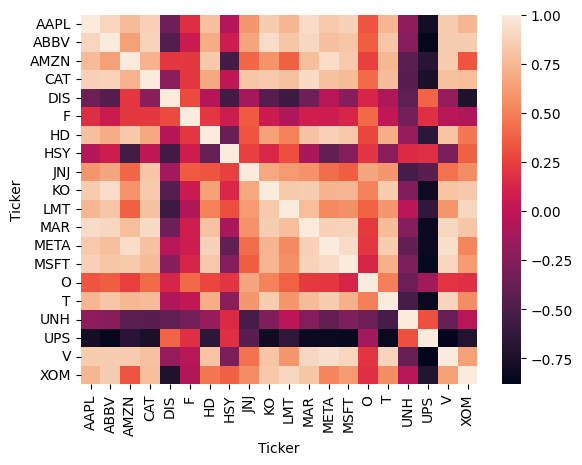

In [8]:
# creation correlation heatmap
port_corr = port_comps_rets_cumprod.corr()

sns.heatmap(port_corr)

In [9]:
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt.expected_returns import ema_historical_return
from pypfopt.risk_models import exp_cov
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.plotting import plot_efficient_frontier
from pypfopt.plotting import plot_weights
from pypfopt.cla import CLA

train = portfolio_returns[:'2024-03-30']
test = portfolio_returns['2024-03-31':]

mu = expected_returns.ema_historical_return(train, returns_data=True, span=500)
Sigma = risk_models.exp_cov(train, returns_data=True, span=180)

In [10]:
mu

,2024-03-28
Ticker,
AAPL,0.061651
ABBV,0.312173
AMZN,0.437980
CAT,0.580036
DIS,0.250055
F,0.221344
HD,0.269038
HSY,-0.028205
JNJ,0.014968


In [11]:
ret_ef = np.arange(0, 1.002519, 0.01)
vol_ef = []
for i in np.arange(0, 1.002519, 0.01):
  ef = EfficientFrontier(mu, Sigma)
  ef.efficient_return(i)
  vol_ef.append(ef.portfolio_performance()[1])

In [12]:
ef = EfficientFrontier(mu, Sigma)
ef.min_volatility()
min_vol_ret = ef.portfolio_performance()[0]
min_vol_vol = ef.portfolio_performance()[1]

In [13]:
ef = EfficientFrontier(mu, Sigma)
ef.max_sharpe(risk_free_rate=0.035)
max_sharpe_ret = ef.portfolio_performance()[0]
max_sharpe_vol = ef.portfolio_performance()[1]

/usr/local/lib/python3.12/dist-packages/pypfopt/efficient_frontier/efficient_frontier.py:441: UserWarning:

The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.



Text(0.5, 1.0, 'Efficient Frontier')

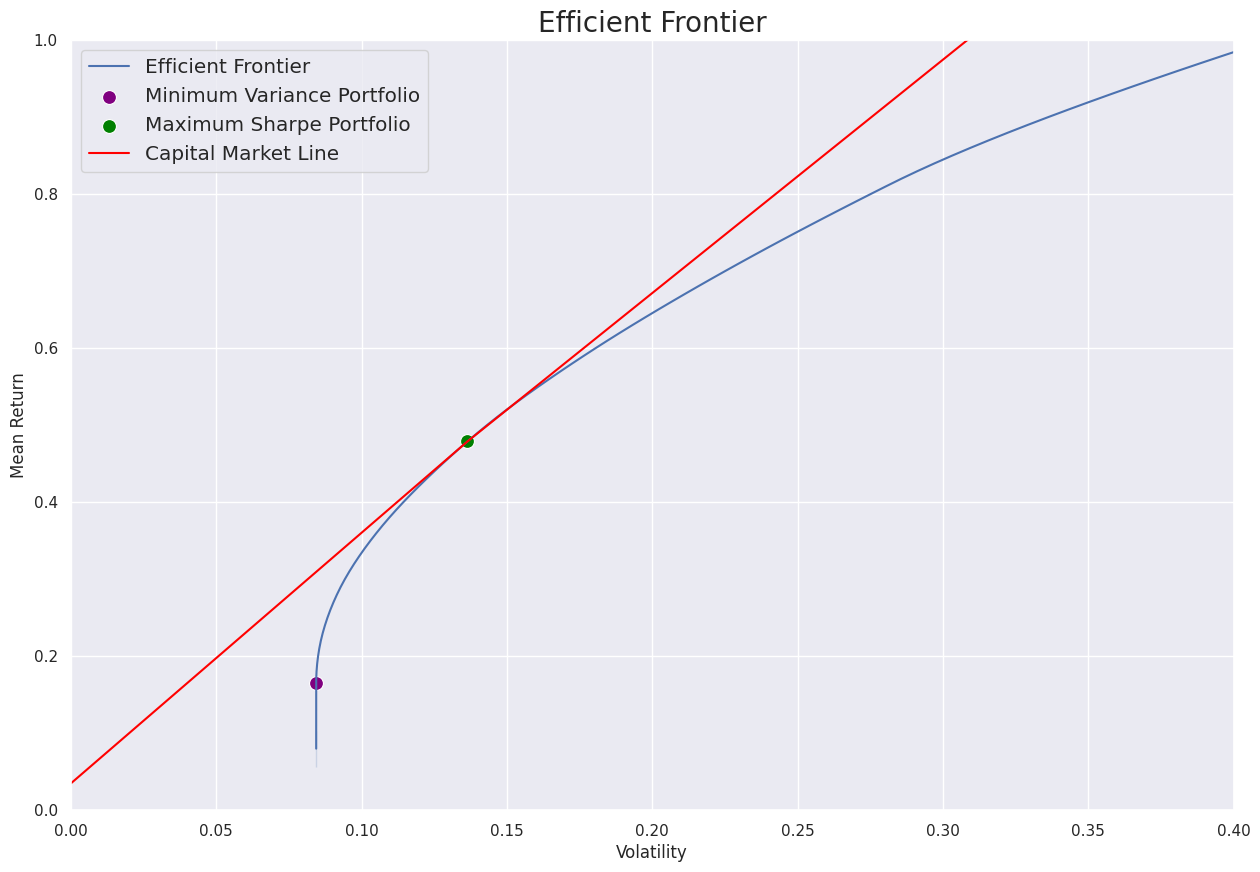

In [14]:
sns.set()

fig, ax = plt.subplots(figsize = [15,10])

sns.lineplot(x=vol_ef, y=ret_ef,
             label='Efficient Frontier',
             ax=ax)

sns.scatterplot(x=[min_vol_vol], y=[min_vol_ret],
                ax=ax,
                label='Minimum Variance Portfolio',
                color='purple', s=100)

sns.scatterplot(x=[max_sharpe_vol], y=[max_sharpe_ret],
                ax=ax,
                label='Maximum Sharpe Portfolio',
                color='green', s=100)

sns.lineplot(x=[0, max_sharpe_vol, 1], y=[0.035, max_sharpe_ret, 3.096],
             label='Capital Market Line',
             ax=ax,
             color='red')

ax.set(xlim = [0, 0.4])
ax.set(ylim = [0, 1])
ax.set_xlabel('Volatility')
ax.set_ylabel('Mean Return')
plt.legend(fontsize='large')
plt.title('Efficient Frontier', fontsize='20')

Expected annual return: 16.6%
Annual volatility: 8.4%
Sharpe Ratio: 1.55


(np.float64(0.16556414901164318),
 np.float64(0.08436398954940343),
 np.float64(1.5476289078906706))

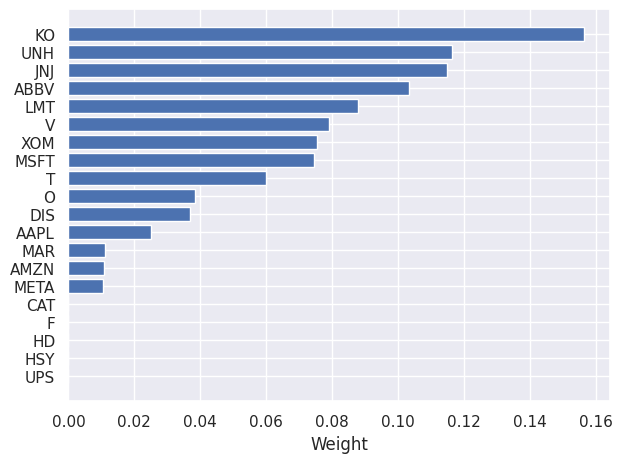

In [15]:
# Minimum Variance
ef = EfficientFrontier(mu, Sigma)
raw_weight_minvar_exp = ef.min_volatility()

plot_weights(raw_weight_minvar_exp)
ef.portfolio_performance(verbose=True, risk_free_rate=0.035)

Expected annual return: 47.9%
Annual volatility: 13.6%
Sharpe Ratio: 3.25


(np.float64(0.47890507594715853),
 np.float64(0.13639531687268777),
 np.float64(3.254547781589175))

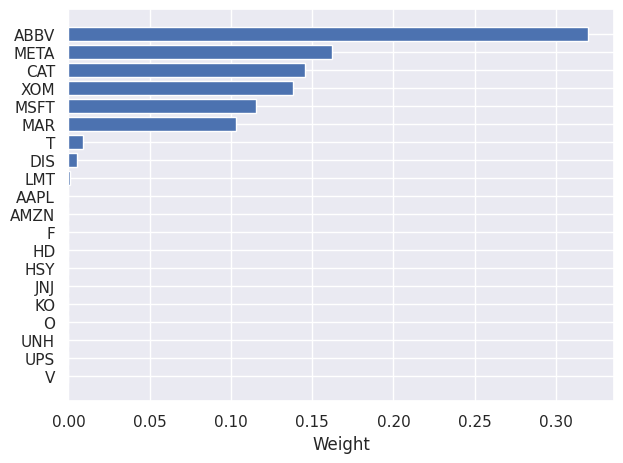

In [16]:
# Maximum Sharpe
ef = EfficientFrontier(mu, Sigma)
raw_weight_maxsharpe_exp = ef.max_sharpe(risk_free_rate=0.035)

plot_weights(raw_weight_maxsharpe_exp)
ef.portfolio_performance(verbose=True, risk_free_rate=0.035)

# Backtesting

In [17]:
weights_min_var_exp = list(raw_weight_minvar_exp.values())
weights_maxsharpe_exp = list(raw_weight_maxsharpe_exp.values())

ret_1 = test.dot(weights_min_var_exp).add(1).cumprod().subtract(1).multiply(100)
ret_2 = test.dot(weights_maxsharpe_exp).add(1).cumprod().subtract(1).multiply(100)

ind_ret = bm_index['Close']['2024-03-31':].pct_change().add(1).cumprod().subtract(1).multiply(100)

In [18]:
back = pd.DataFrame({'MinVar':ret_1, 'MaxSharpe':ret_2})
back = pd.concat([back, ind_ret], join='outer', axis=1)
back.drop(back.tail(1).index, inplace=True)

back.interpolate(method='linear', inplace=True)

fig = px.line(back, x=back.index, y=back.columns, title='Portfolio Performance')
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Cumulative Return %')

**Next step**: source asset class return expectations

In [19]:
print("Hello, World!")

Hello, World!
